<h2 style="color:#34495e;">Perceptron Algorithm – Placement Prediction</h2>

<hr style="border:1px solid #ddd;">

**🎯 Aim:** To implement a binary classification model using the Perceptron algorithm to predict student placement based on CGPA and resume score.

**📂 Dataset:** placement.csv

**🧾 Features:**  
• CGPA  
• Resume Score
**🏷️ Target Variable:** Placed (0 = Not Placed, 1 = Placed)

**🤖 Algorithm Used:** Perceptron (Scikit-learn)

**🛠️ Tools / Libraries:** Python, Pandas, NumPy, Matplotlib, Scikit-learn

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

### Load the Dataset

In [2]:
# Load CSV file
data = pd.read_csv(r"C:\Users\hp\Desktop\DL4\placement.csv")

print(data.head())

   cgpa  resume_score  placed
0  8.14          6.52       1
1  6.17          5.17       0
2  8.27          8.86       1
3  6.88          7.27       1
4  7.52          7.30       1


In [3]:
print(data.shape)

(100, 3)


### Scatter Plot (Before Training)

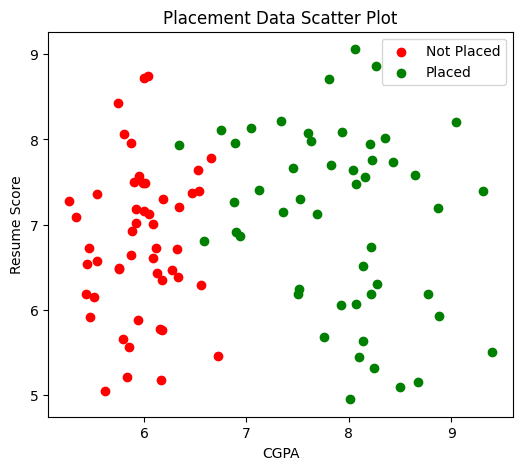

In [4]:
plt.figure(figsize=(6, 5))

# Class 0 (Not Placed)
plt.scatter(
    data[data['placed'] == 0]['cgpa'],
    data[data['placed'] == 0]['resume_score'],
    color='red',
    label='Not Placed'
)

# Class 1 (Placed)
plt.scatter(
    data[data['placed'] == 1]['cgpa'],
    data[data['placed'] == 1]['resume_score'],
    color='green',
    label='Placed'
)

plt.xlabel("CGPA")
plt.ylabel("Resume Score")
plt.legend()
plt.title("Placement Data Scatter Plot")
plt.show()

### Separate features and target

In [5]:
X = data[['cgpa', 'resume_score']].values   # input features
y = data['placed'].values                  # output label

### (Important) Feature Scaling

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Train the Perceptron

In [7]:
model = Perceptron(
    max_iter=1000,
    eta0=0.01,
    random_state=42
)

model.fit(X_scaled, y)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,0.01
,n_jobs,None
,random_state,42


### Predictions & Accuracy

In [8]:
y_pred = model.predict(X_scaled)

print("Accuracy:", accuracy_score(y, y_pred))

Accuracy: 0.97


### Decision Boundary

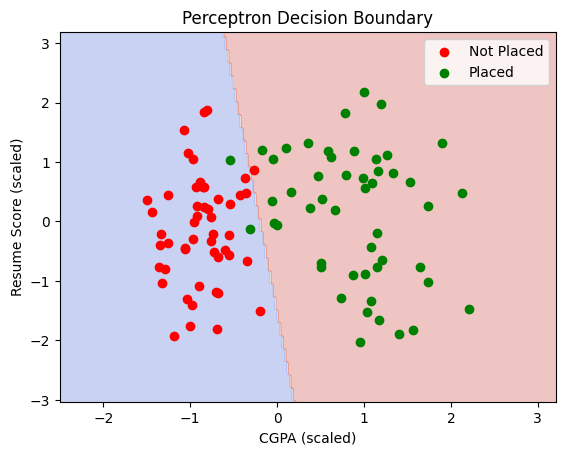

In [9]:
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_scaled[y == 0, 0], X_scaled[y == 0, 1], color='red', label='Not Placed')
plt.scatter(X_scaled[y == 1, 0], X_scaled[y == 1, 1], color='green', label='Placed')

plt.xlabel("CGPA (scaled)")
plt.ylabel("Resume Score (scaled)")
plt.legend()
plt.title("Perceptron Decision Boundary")
plt.show()

<h2 style="color:#34495e;">Results & Analysis</h2>

<hr style="border:1px solid #ddd;">

**✅ Result:**  
The perceptron model was successfully trained on the placement dataset. It was able to classify students as placed or not placed with reasonable accuracy.

**📊 Conclusion:**  
From the scatter plot and decision boundary, it is observed that the data is approximately linearly separable. Hence, the perceptron algorithm is suitable for this classification problem.

**⚠️ Limitations:**  
- The perceptron algorithm works only for linearly separable data.  
- It may fail when classes overlap.  
- More complex models such as logistic regression or neural networks can be used for better performance.